In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
"""
Unsupervised DBSCAN Clustering on Sensor Data
===============================================
Dataset: 1600 breakdowns × 20 sensors (values between -1 and +1)
Goal: Let DBSCAN automatically find clusters based on density.

DBSCAN doesn't need you to specify k — it finds clusters on its own.
It also identifies "noise" points that don't belong to any cluster.
"""

import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [ ]:
# --------------------------------------------------
# Step 1: Load and scale the data
# --------------------------------------------------
df = pd.read_csv('/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/data_sensors.csv')

sensor_cols = [f'Sensor {i}' for i in range(20)]
X = df[sensor_cols].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Dataset shape: {X_scaled.shape}")
print(f"(1600 breakdowns, 20 sensor features)\n")

Dataset shape: (1600, 20)
(1600 breakdowns, 20 sensor features)



Computing 5-nearest neighbor distances...


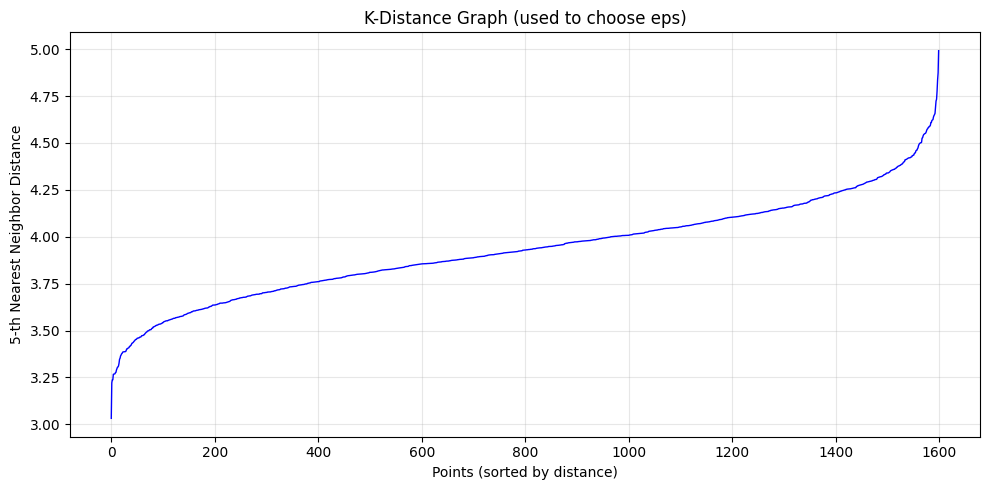

In [ ]:
# --------------------------------------------------
# Step 2: Find a good 'eps' using the k-distance graph
# --------------------------------------------------
# Rule of thumb: use min_samples = 2 * n_features = 2 * 20 = 40
# But for 1600 points with 20 dims, we'll try min_samples = 5 (more practical)
# We plot the k-nearest neighbor distance to find the "elbow" for eps.

min_samples = 5  # Minimum points to form a dense region

print(f"Computing {min_samples}-nearest neighbor distances...")
nn = NearestNeighbors(n_neighbors=min_samples)
nn.fit(X_scaled)
distances, _ = nn.kneighbors(X_scaled)

# Sort the distances to the k-th nearest neighbor
k_distances = np.sort(distances[:, -1])

# Plot k-distance graph
plt.figure(figsize=(10, 5))
plt.plot(k_distances, 'b-', linewidth=1)
plt.xlabel('Points (sorted by distance)')
plt.ylabel(f'{min_samples}-th Nearest Neighbor Distance')
plt.title('K-Distance Graph (used to choose eps)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Step 3: Try multiple eps values to find the best one
# --------------------------------------------------
print("Testing different eps values...")
print("-" * 55)

eps_values = np.arange(2.0, 5.5, 0.5)
results = []

for eps in eps_values:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(X_scaled)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    n_noise = (labels == -1).sum()
    noise_pct = n_noise / len(labels) * 100
    results.append((eps, n_clusters, n_noise, noise_pct))
    print(f"eps={eps:.1f} | Clusters: {n_clusters:3d} | Noise points: {n_noise:4d} ({noise_pct:.1f}%)")

print("-" * 55)

Testing different eps values...
-------------------------------------------------------
eps=2.0 | Clusters:   0 | Noise points: 1600 (100.0%)
eps=2.5 | Clusters:   0 | Noise points: 1600 (100.0%)
eps=3.0 | Clusters:   0 | Noise points: 1600 (100.0%)
eps=3.5 | Clusters:  20 | Noise points: 1327 (82.9%)
eps=4.0 | Clusters:   2 | Noise points:  139 (8.7%)
eps=4.5 | Clusters:   1 | Noise points:    2 (0.1%)
eps=5.0 | Clusters:   1 | Noise points:    0 (0.0%)
-------------------------------------------------------


In [ ]:
# --------------------------------------------------
# Step 4: Pick a reasonable eps (balance clusters vs noise)
# --------------------------------------------------
# We want: more than 1 cluster, and noise < 50%
good_results = [(e, nc, nn, np_) for e, nc, nn, np_ in results if nc >= 2 and np_ < 50]

if good_results:
    # Pick the one with most clusters and reasonable noise
    best = max(good_results, key=lambda x: x[1])
    best_eps = best[0]
    print(f"\nChosen eps={best_eps:.1f} (Clusters: {best[1]}, Noise: {best[2]} points)")
else:
    # Fallback: use eps where we get at least some structure
    best_eps = 3.5
    print(f"\nNo ideal eps found. Using eps={best_eps:.1f} as fallback.")


Chosen eps=4.0 (Clusters: 2, Noise: 139 points)


In [ ]:
# --------------------------------------------------
# Step 5: Run final DBSCAN
# --------------------------------------------------
print(f"\nRunning final DBSCAN (eps={best_eps}, min_samples={min_samples})...")
dbscan_final = DBSCAN(eps=best_eps, min_samples=min_samples)
cluster_labels = dbscan_final.fit_predict(X_scaled)

n_clusters = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
n_noise = (cluster_labels == -1).sum()

print(f"\nResults:")
print(f"  Number of clusters found: {n_clusters}")
print(f"  Noise points (no cluster): {n_noise} ({n_noise/len(cluster_labels)*100:.1f}%)")
print(f"\nCluster Distribution:")
print("-" * 30)
for c in sorted(set(cluster_labels)):
    count = (cluster_labels == c).sum()
    label = f"Cluster {c}" if c != -1 else "Noise (-1)"
    print(f"  {label}: {count} breakdowns")


Running final DBSCAN (eps=4.0, min_samples=5)...

Results:
  Number of clusters found: 2
  Noise points (no cluster): 139 (8.7%)

Cluster Distribution:
------------------------------
  Noise (-1): 139 breakdowns
  Cluster 0: 1460 breakdowns
  Cluster 1: 1 breakdowns


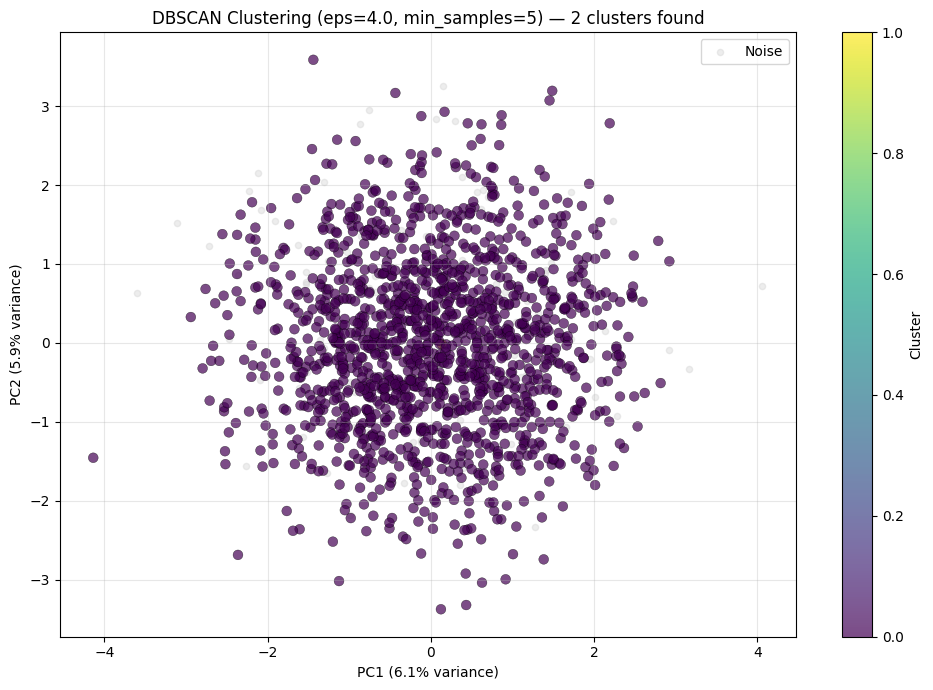

In [ ]:
# --------------------------------------------------
# Step 6: Visualize clusters using PCA (2D)
# --------------------------------------------------
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))

# Plot noise points in gray
noise_mask = cluster_labels == -1
if noise_mask.any():
    plt.scatter(X_pca[noise_mask, 0], X_pca[noise_mask, 1],
                c='lightgray', alpha=0.4, s=20, label='Noise')

# Plot clustered points with colors
clustered_mask = cluster_labels != -1
scatter = plt.scatter(X_pca[clustered_mask, 0], X_pca[clustered_mask, 1],
                      c=cluster_labels[clustered_mask], cmap='viridis',
                      alpha=0.7, edgecolors='k', linewidth=0.3, s=50)
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.title(f'DBSCAN Clustering (eps={best_eps}, min_samples={min_samples}) — {n_clusters} clusters found')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# --------------------------------------------------
# Step 7: Save results
# --------------------------------------------------
df['DBSCAN_Cluster'] = cluster_labels
output_df = df[sensor_cols + ['DBSCAN_Cluster']].copy()
output_df.to_csv('/content/drive/MyDrive/Take-Home-Assignment/ML6/Customer-A/results/dbscan_results.csv', index=False)
print("Saved: dbscan_results.csv")

print("\nDone!")

Saved: dbscan_results.csv

Done!


# The End